# Experiment 1 · Notebook 3 — Apply POW Model to Era-Adjusted History

**Goal:** Take the POW model trained in notebook 2 and apply it to **era-adjusted** career stats for every batter in MLB history. The result is an OOTP-compatible POW rating for players from any era — the whole point of the project.

**Source:** the [`fullhouse`](https://github.com/DEck13/fullhouse) R package (Eck et al., 2025), which provides Full House Modeling-based career batting stats for ~9,600 batters through 2024. The era adjustment puts Babe Ruth's 1921 and Aaron Judge's 2024 on a comparable scale.

## Prerequisite — run the R extraction script first

`fullhouse` and `Lahman` are R packages, and the cleanest path is to let R do the joining and produce a CSV. From the `experiment1/` directory:

```bash
Rscript extract_era_adjusted_data.R
```

That writes `data/era_adjusted_batters.csv` with era-adjusted career stats joined to handedness, which this notebook reads.

**Outputs**
- `data/historical_pow_predictions.csv` — one row per historical batter, sorted by predicted POW
- `outputs/historical_pow_distribution.png` — histogram of predictions
- `outputs/era_adjusted_top20.png` — bar chart of the top 20

## 1. Setup

In [17]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

plt.style.use("seaborn-v0_8-whitegrid")
%matplotlib inline

# Inputs
TRAINING_PATH      = Path("data/training_data.csv")
ERA_ADJUSTED_CSV   = Path("data/era_adjusted_batters.csv")

# Outputs
PREDICTIONS_PATH   = Path("data/historical_pow_predictions.csv")
PLOT_HIST          = Path("outputs/historical_pow_distribution.png")
PLOT_TOP20         = Path("outputs/era_adjusted_top20.png")

# Config
FEATURE_COLS = ["hr_per_600", "bats_L", "bats_S"]
PA_THRESHOLD = 500

PREDICTIONS_PATH.parent.mkdir(parents=True, exist_ok=True)
PLOT_HIST.parent.mkdir(parents=True, exist_ok=True)


## 2. Load era-adjusted batters (with handedness)

Single read of the CSV produced by `extract_era_adjusted_data.R`. The R script has already done all the cross-package joining — fullhouse stats + Lahman handedness in one frame.

In [18]:
if not ERA_ADJUSTED_CSV.exists():
    raise FileNotFoundError(
        f"{ERA_ADJUSTED_CSV} not found.\n"
        "Run `Rscript extract_era_adjusted_data.R` from the experiment1 "
        "directory first to generate it from the fullhouse R package."
    )

df = pd.read_csv(ERA_ADJUSTED_CSV)
df["playerID"] = df["playerID"].astype(str).str.strip()

n_rows = len(df)
cols   = list(df.columns)
print(f"Loaded {n_rows:,} batters from {ERA_ADJUSTED_CSV}")
print(f"Columns: {cols}")
df.head()


Loaded 9,637 batters from data/era_adjusted_batters.csv
Columns: ['playerID', 'name', 'nameFirst', 'nameLast', 'bats', 'throws', 'PA', 'AB', 'H', 'HR', 'BB', 'BA', 'OBP', 'HBP', 'SF', 'ebWAR', 'efWAR']


,playerID,name,nameFirst,nameLast,bats,throws,PA,AB,H,HR,BB,BA,OBP,HBP,SF,ebWAR,efWAR
0,aardsda01,David Aardsma,David,Aardsma,R,R,80,67,20,2,13,0.299,0.412,0,0,1.16,1.17
1,aaronha01,Henry Aaron,Hank,Aaron,R,R,14113,12540,3886,690,1420,0.310,0.378,32,121,135.67,127.96
2,aaronto01,Tommie Aaron,Tommie,Aaron,R,R,581,521,110,6,55,0.211,0.284,0,5,-1.67,-1.64
3,abadfe01,Fernando Abad,Fernando,Abad,L,L,128,112,32,1,16,0.286,0.375,0,0,0.86,0.84
4,abbotco01,Cory Abbott,Cory,Abbott,R,R,47,43,12,1,4,0.279,0.340,0,0,0.33,0.27


## 3. Normalize handedness

Lahman uses `B` for switch hitters; the model we trained in Experiment 1 uses `S`. Default missing handedness to `R` (the modal category). Handedness offsets in the trained model are small (~1.5 POW points), so the imputation has minimal impact even where it's needed.

In [19]:
n_missing = df["bats"].isna().sum()
df["bats"] = df["bats"].fillna("R").replace({"B": "S"})
bats_split = dict(df["bats"].value_counts())
print(f"Missing handedness imputed to R: {n_missing:,}")
print(f"Final bats split: {bats_split}")


Missing handedness imputed to R: 76
Final bats split: {'R': np.int64(6144), 'L': np.int64(2800), 'S': np.int64(693)}


## 4. Feature engineering and PA filter

Same recipe as notebook 1: `hr_per_600 = (HR / PA) * 600`, one-hot encode handedness with R as the reference, filter to `PA ≥ 500`.

In [20]:
df_filt = df[df["PA"] >= PA_THRESHOLD].copy()
df_filt["hr_per_600"] = (df_filt["HR"] / df_filt["PA"]) * 600
df_filt["bats_L"] = (df_filt["bats"] == "L").astype(int)
df_filt["bats_S"] = (df_filt["bats"] == "S").astype(int)

n_kept = len(df_filt); n_drop = len(df) - n_kept
print(f"After PA >= {PA_THRESHOLD}: {n_kept:,} historical batters (dropped {n_drop:,})")
hr_lo = df_filt["hr_per_600"].min()
hr_hi = df_filt["hr_per_600"].max()
print(f"hr_per_600 range: {hr_lo:.1f} - {hr_hi:.1f}")


After PA >= 500: 4,168 historical batters (dropped 5,469)
hr_per_600 range: 0.0 - 39.0


## 5. Re-train the POW model on the modern overlap

Notebook 2 fits both models on an 80/20 train split for honest evaluation. For *applying* the model to history we want every drop of signal we have, so we re-fit on the **full** training set produced by notebook 1.

In [21]:
training = pd.read_csv(TRAINING_PATH)
src_label = training["source"].iloc[0] if "source" in training.columns else "unknown"
print(f"Training rows: {len(training):,} (source: {src_label})")

X_train = training[FEATURE_COLS]
y_train = training["POW"]

linear = LinearRegression().fit(X_train, y_train)
poly = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    LinearRegression(),
).fit(X_train, y_train)

print("Linear coefficients (re-fit on the full training set):")
for name, coef in zip(FEATURE_COLS, linear.coef_):
    print(f"  {name:>12}: {coef:+.3f}")
print(f"  {'intercept':>12}: {linear.intercept_:+.3f}")


Training rows: 441 (source: mlb_api)
Linear coefficients (re-fit on the full training set):
    hr_per_600: +1.367
        bats_L: +1.993
        bats_S: +2.242
     intercept: +22.115


## 6. Predict POW for every historical batter

Generate raw predictions from both models. Clip to `[20, 80]` and round to get the OOTP-compatible integer POW; keep the unclamped linear prediction alongside for debugging.

In [22]:
X_hist = df_filt[FEATURE_COLS]
df_filt["pred_pow_linear"] = linear.predict(X_hist)
df_filt["pred_pow_poly"]   = poly.predict(X_hist)
df_filt["pow"]      = df_filt["pred_pow_linear"].clip(20, 80).round().astype(int)
df_filt["pow_poly"] = df_filt["pred_pow_poly"].clip(20, 80).round().astype(int)

print("Summary of predicted POW (linear, clamped):")
print(df_filt["pow"].describe().round(1).to_string())


Summary of predicted POW (linear, clamped):
count    4168.0
mean       39.2
std         9.3
min        22.0
25%        32.0
50%        38.0
75%        45.0
max        77.0


## 7. Sanity-check predictions on the all-time greats

Famous power hitters should land near 80; defensive specialists and pitchers-as-batters should land near 20.

In [23]:
known = {
    "ruthba01":  "Babe Ruth",
    "bondsba01": "Barry Bonds",
    "aaronha01": "Hank Aaron",
    "willite01": "Ted Williams",
    "mantlmi01": "Mickey Mantle",
    "mayswi01":  "Willie Mays",
    "foxxji01":  "Jimmie Foxx",
    "rodrial01": "Alex Rodriguez",
    "pujolal01": "Albert Pujols",
    "judgeaa01": "Aaron Judge",
    "ohtansh01": "Shohei Ohtani",
    "wagneho01": "Honus Wagner",
    "suzukic01": "Ichiro Suzuki",
    "smithoz01": "Ozzie Smith",
    "carewro01": "Rod Carew",
}

mask = df_filt["playerID"].isin(known.keys())
sanity = df_filt.loc[mask, ["playerID", "name", "bats", "PA", "HR",
                            "hr_per_600", "pred_pow_linear", "pow"]].copy()
sanity = sanity.sort_values("pred_pow_linear", ascending=False)
sanity.round({'hr_per_600': 1, 'pred_pow_linear': 1})


,playerID,name,bats,PA,HR,hr_per_600,pred_pow_linear,pow
7582,ruthba01,Babe Ruth,L,10829,703,39.0,77.4,77
4411,judgeaa01,Aaron Judge,R,4579,253,33.2,67.4,67
826,bondsba01,Barry Bonds,L,12740,651,30.7,66.0,66
2852,foxxji01,Jimmie Foxx,R,9322,495,31.9,65.7,66
5309,mantlmi01,Mickey Mantle,S,10128,500,29.6,64.9,65
9383,willite01,Ted Williams,L,10184,500,29.5,64.4,64
6356,ohtansh01,Shohei Ohtani,L,3877,189,29.2,64.1,64
6927,pujolal01,Albert Pujols,R,13253,663,30.0,63.2,63
1,aaronha01,Henry Aaron,R,14113,690,29.3,62.2,62
7359,rodrial01,Alex Rodriguez,R,11917,547,27.5,59.8,60


## 8. Top 25 and bottom 25 by predicted POW

In [24]:
top25 = df_filt.nlargest(25, "pred_pow_linear")[
    ["playerID", "name", "bats", "PA", "HR", "hr_per_600", "pred_pow_linear", "pow"]
]
top25.round({'hr_per_600': 1, 'pred_pow_linear': 1})


,playerID,name,bats,PA,HR,hr_per_600,pred_pow_linear,pow
7582,ruthba01,Babe Ruth,L,10829,703,39.0,77.4,77
5632,mcgwima01,Mark McGwire,R,7668,484,37.9,73.9,74
7782,schimry01,Ryan Schimpf,L,633,38,36.0,73.4,73
4583,kingmda01,Dave Kingman,R,7697,462,36.0,71.4,71
4161,jacksbo01,Bo Jackson,R,2154,129,35.9,71.2,71
8286,stargwi01,Willie Stargell,L,9210,527,34.3,71.0,71
4607,kittlro01,Ron Kittle,R,2983,173,34.8,69.7,70
8284,stantmi03,Giancarlo Stanton,R,7243,419,34.7,69.6,70
4574,kinerra01,Ralph Kiner,R,6347,359,33.9,68.5,69
410,balbost01,Steve Balboni,R,3180,179,33.8,68.3,68


In [25]:
bot25 = df_filt.nsmallest(25, "pred_pow_linear")[
    ["playerID", "name", "bats", "PA", "HR", "hr_per_600", "pred_pow_linear", "pow"]
]
bot25.round({'hr_per_600': 1, 'pred_pow_linear': 1})


,playerID,name,bats,PA,HR,hr_per_600,pred_pow_linear,pow
604,bellga01,Gary Bell,R,509,0,0.0,22.1,22
1001,brideji01,Jim Brideweser,R,894,0,0.0,22.1,22
1005,bridgto01,Tommy Bridges,R,943,0,0.0,22.1,22
1184,burkejo03,John Burkett,R,517,0,0.0,22.1,22
2482,ehmkeho01,Howard Ehmke,R,503,0,0.0,22.1,22
3393,grimebu01,Burleigh Grimes,R,1646,0,0.0,22.1,22
4061,hudsosi01,Sid Hudson,R,1002,0,0.0,22.1,22
4173,jacksla01,Larry Jackson,R,737,0,0.0,22.1,22
4378,jonessa02,Sam Jones,R,586,0,0.0,22.1,22
6055,mungova01,Van Mungo,R,733,0,0.0,22.1,22


## 9. Distribution and visualization

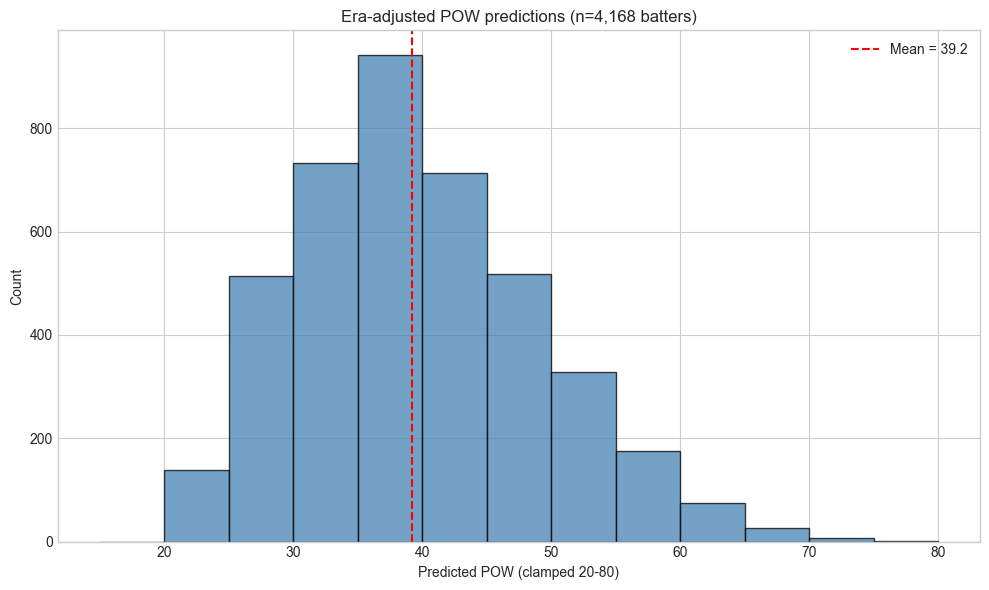

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df_filt["pow"], bins=range(15, 85, 5), edgecolor="black", alpha=0.75, color="steelblue")
mean_pow = df_filt["pow"].mean()
ax.axvline(mean_pow, color="red", linestyle="--", label=f"Mean = {mean_pow:.1f}")
ax.set_xlabel("Predicted POW (clamped 20-80)")
ax.set_ylabel("Count")
n_total = len(df_filt)
ax.set_title(f"Era-adjusted POW predictions (n={n_total:,} batters)")
ax.legend()
fig.tight_layout()
fig.savefig(PLOT_HIST, dpi=130)
plt.show()


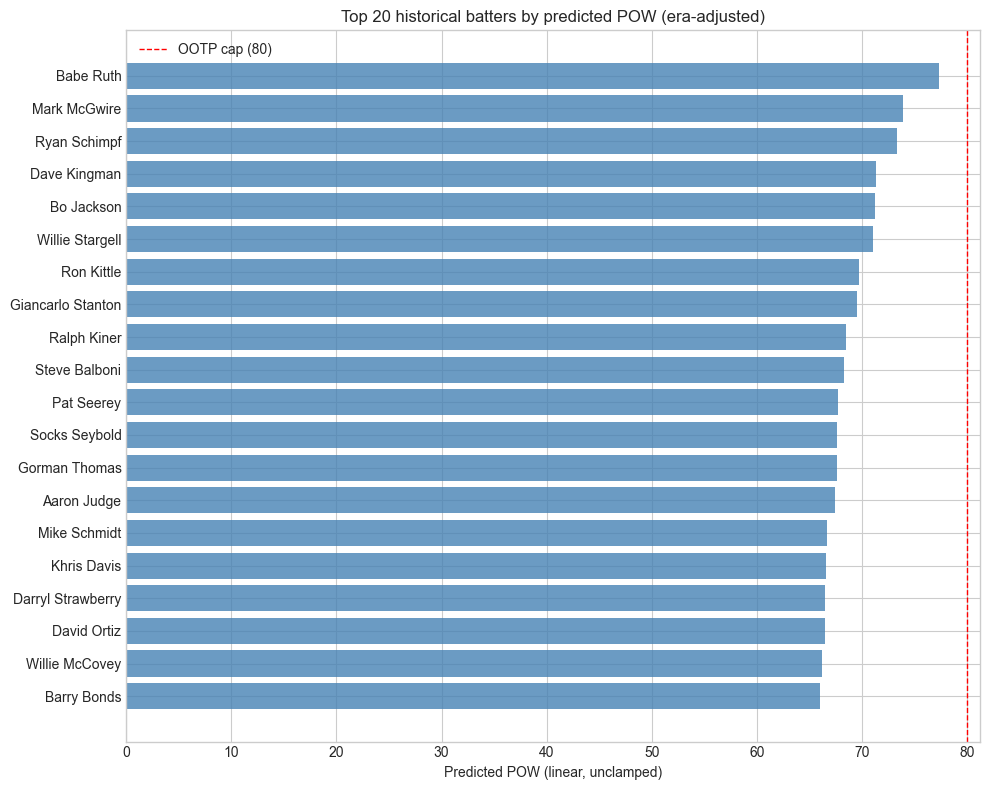

In [27]:
top20 = df_filt.nlargest(20, "pred_pow_linear")

fig, ax = plt.subplots(figsize=(10, 8))
y_pos = np.arange(len(top20))
ax.barh(y_pos, top20["pred_pow_linear"], color="steelblue", alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(top20["name"])
ax.invert_yaxis()
ax.set_xlabel("Predicted POW (linear, unclamped)")
ax.set_title("Top 20 historical batters by predicted POW (era-adjusted)")
ax.axvline(80, color="red", linestyle="--", linewidth=1, label="OOTP cap (80)")
ax.legend()
fig.tight_layout()
fig.savefig(PLOT_TOP20, dpi=130)
plt.show()


## 10. Save predictions

Write a clean CSV that downstream notebooks (and eventually the OOTP import step) can pick up.

In [28]:
out_cols = [
    "playerID", "name", "bats",
    "PA", "HR", "hr_per_600",
    "pred_pow_linear", "pred_pow_poly",
    "pow", "pow_poly",
]
df_filt[out_cols].sort_values("pred_pow_linear", ascending=False).to_csv(
    PREDICTIONS_PATH, index=False
)
print(f"Saved {len(df_filt):,} predictions -> {PREDICTIONS_PATH}")


Saved 4,168 predictions -> data/historical_pow_predictions.csv


## What's next

- Repeat this notebook for **every other rating** (`CON`, `EYE`, `SPE`, fielding, arm) once the corresponding notebook-1 / notebook-2 pairs exist. The structure here is reusable: fit on the modern training data, apply to era-adjusted history, save predictions.
- For pitchers, do the same with `pitchers_career_adjusted` from the fullhouse package — extend `extract_era_adjusted_data.R` to dump a second CSV.
- Once all rating predictions are stitched together, format as an OOTP roster CSV and import into a custom league. That's the endgame.